In [1]:
import pandas as pd 
import shap

data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/PengamanJaringan/dataset/Obfuscated-MalMem2022.csv')
data

/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58591,Ransomware-Shade-fa03be3078d1b9840f06745f160eb...,37,15,10.108108,0,215.486487,1453,39.270270,7973,215.486487,...,221,26,24,116,0,120,86,0,8,Malware
58592,Ransomware-Shade-f56687137caf9a67678cde91e4614...,37,14,9.945946,0,190.216216,1347,36.405405,7038,190.216216,...,221,26,24,116,0,116,88,0,8,Malware
58593,Ransomware-Shade-faddeea111a25da4d0888f3044ae9...,38,15,9.842105,0,210.026316,1448,38.105263,7982,215.729730,...,221,26,24,116,0,120,88,0,8,Malware
58594,Ransomware-Shade-f866c086af2e1d8ebaa6f2c863157...,37,15,10.243243,0,215.513513,1452,39.243243,7974,215.513513,...,221,26,24,116,0,120,87,0,8,Malware


In [2]:
# Extract the part before the underscore symbol
data['Category_new'] = [label.split('-')[0] for label in data['Category']]

data["Category_new"].unique()

<StringArray>
['Benign', 'Ransomware', 'Spyware', 'Trojan']
Length: 4, dtype: str

In [3]:
data =data.drop(columns=['Class','Category'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 58596 entries, 0 to 58595
Data columns (total 56 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   pslist.nproc                            58596 non-null  int64  
 1   pslist.nppid                            58596 non-null  int64  
 2   pslist.avg_threads                      58596 non-null  float64
 3   pslist.nprocs64bit                      58596 non-null  int64  
 4   pslist.avg_handlers                     58596 non-null  float64
 5   dlllist.ndlls                           58596 non-null  int64  
 6   dlllist.avg_dlls_per_proc               58596 non-null  float64
 7   handles.nhandles                        58596 non-null  int64  
 8   handles.avg_handles_per_proc            58596 non-null  float64
 9   handles.nport                           58596 non-null  int64  
 10  handles.nfile                           58596 non-null  int64  
 11  

In [4]:
data['Category_new'].value_counts()

Category_new
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64

In [19]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
lb = LabelEncoder()
data['Category_new']= lb.fit_transform(data['Category_new'])
data['Category_new'].unique()

array([0, 1, 2, 3])

In [20]:
# ✅ Ambil class_labels dari LabelEncoder SETELAH fit_transform
class_labels = list(lb.classes_)  # ['Benign', 'Ransomware', 'Spyware', 'Trojan'] (sesuai data)
class_labels

['Benign', 'Ransomware', 'Spyware', 'Trojan']

In [21]:
from sklearn.model_selection import train_test_split

X = data.drop('Category_new', axis=1)
y = data['Category_new']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (46876, 55)
Shape of X_test: (11720, 55)
Shape of y_train: (46876,)
Shape of y_test: (11720,)


#### Training Xgboost

In [22]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,f1_score, classification_report

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import time


# ── Helper ──────────────────────────────────────────────────────────────────
def print_metrics(name, y_true, y_pred, training_time=None, testing_time=None):
    print(f"\n{'='*50}")
    print(f"  {name} Results")
    print(f"{'='*50}")
    if training_time is not None:
        print(f"  Training Time : {training_time:.4f}s")
    if testing_time is not None:
        print(f"  Testing Time  : {testing_time:.4f}s")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Precision Macro : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  Recall Macro   : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"  F1-Score Macro : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=[str(x) for x in class_labels], zero_division=0))

# 1. Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)
start = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start

start = time.time()
y_pred_rf = rf_model.predict(X_test)
rf_test_time = time.time() - start

print_metrics("Random Forest", y_test, y_pred_rf, training_time=rf_time, testing_time=rf_test_time)

# 2. XGBoost Classifier
print("\n--- Training XGBoost Classifier ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    random_state=42
)
start = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start

start = time.time()
y_pred_xgb = xgb_model.predict(X_test)
xgb_test_time = time.time() - start

print_metrics("XGBoost", y_test, y_pred_xgb, training_time=xgb_time, testing_time=xgb_test_time)

# 3. LightGBM Classifier
print("\n--- Training LightGBM Classifier ---")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=None,
    learning_rate=0.2,
    class_weight='balanced',
    random_state=42,
    verbose = -1
)
start = time.time()
lgbm_model.fit(X_train, y_train)
lgbm_time = time.time() - start

start = time.time()
y_pred_lgbm = lgbm_model.predict(X_test)
lgbm_test_time = time.time() - start

print_metrics("LightGBM", y_test, y_pred_lgbm, training_time=lgbm_time, testing_time=lgbm_test_time)


--- Training Random Forest Classifier ---

  Random Forest Results
  Training Time : 12.1660s
  Testing Time  : 0.2077s
  Accuracy  : 0.8709
  Precision : 0.8707
  Precision Macro : 0.8057
  Recall    : 0.8709
  Recall Macro   : 0.8058
  F1-Score  : 0.8708
  F1-Score Macro : 0.8057

  Classification Report:

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.72      0.72      0.72      1958
     Spyware       0.78      0.80      0.79      2004
      Trojan       0.72      0.70      0.71      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720


--- Training XGBoost Classifier ---

  XGBoost Results
  Training Time : 2.8222s
  Testing Time  : 0.0231s
  Accuracy  : 0.8816
  Precision : 0.8814
  Precision Macro : 0.8220
  Recall    : 0.8816
  Recall Macro   : 0.8218
  F1-Score  : 0.8813
  F1-Scor

In [24]:
# ── Rekap Perbandingan Semua Model ─────────────────────────────────────────
import pandas as pd

def collect_metrics(name, y_true, y_pred, train_time=None, test_time=None):
    return {
        "Model"              : name,
        "F1 Macro"           : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        "F1 Weighted"        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall Macro"       : recall_score(y_true, y_pred, average='macro',    zero_division=0),
        "Recall Weighted"    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Precision Macro"    : precision_score(y_true, y_pred, average='macro',    zero_division=0),
        "Precision Weighted" : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Accuracy"           : accuracy_score(y_true, y_pred),
        "Train Time (s)"     : round(train_time, 4) if train_time is not None else None,
        "Test Time (s)"      : round(test_time, 4) if test_time is not None else None,
    }

results = [
    collect_metrics("Random Forest", y_test, y_pred_rf,   rf_time,   rf_test_time),
    collect_metrics("XGBoost",       y_test, y_pred_xgb,  xgb_time,  xgb_test_time),
    collect_metrics("LightGBM",      y_test, y_pred_lgbm, lgbm_time, lgbm_test_time),
]

df_recap = pd.DataFrame(results).set_index("Model")

# Format 4 desimal untuk semua kolom numerik
fmt_cols = ["F1 Macro", "F1 Weighted", "Recall Macro", "Recall Weighted",
            "Precision Macro", "Precision Weighted", "Accuracy"]
df_display = df_recap.copy()
df_display[fmt_cols] = df_display[fmt_cols].map(lambda x: f"{x:.4f}")

# ── Tampilkan rekap ────────────────────────────────────────────────────────
print("\n" + "="*80)
print("  REKAP PERBANDINGAN MODEL")
print("="*80)

# Urutkan berdasarkan F1 Macro (descending)
df_sorted = df_recap.sort_values("F1 Macro", ascending=False)

metric_order = [
    ("F1 Macro",           "F1-Score Macro   "),
    ("F1 Weighted",        "F1-Score Weighted"),
    ("Recall Macro",       "Recall Macro     "),
    ("Recall Weighted",    "Recall Weighted  "),
    ("Precision Macro",    "Precision Macro  "),
    ("Precision Weighted", "Precision Weighted"),
    ("Accuracy",           "Accuracy         "),
]

for col, label in metric_order:
    print(f"\n  Ranking — {label.strip()}")
    print(f"  {'-'*40}")
    ranked = df_recap[col].sort_values(ascending=False)
    for rank, (model, val) in enumerate(ranked.items(), 1):
        marker = " ✓ TERBAIK" if rank == 1 else ""
        print(f"  {rank}. {model:<20} {val:.4f}{marker}")

# ── Tabel ringkasan lengkap ────────────────────────────────────────────────
print("\n" + "="*80)
print("  TABEL RINGKASAN LENGKAP")
print("="*80)
print(df_display.to_string())

# ── Model terbaik per metrik ───────────────────────────────────────────────
print("\n" + "="*80)
print("  MODEL TERBAIK PER METRIK")
print("="*80)
for col, label in metric_order:
    best_model = df_recap[col].idxmax()
    best_val   = df_recap[col].max()
    print(f"  {label.strip():<22} → {best_model:<20} ({best_val:.4f})")
print("="*80)


  REKAP PERBANDINGAN MODEL

  Ranking — F1-Score Macro
  ----------------------------------------
  1. XGBoost              0.8216 ✓ TERBAIK
  2. LightGBM             0.8178
  3. Random Forest        0.8057

  Ranking — F1-Score Weighted
  ----------------------------------------
  1. XGBoost              0.8813 ✓ TERBAIK
  2. LightGBM             0.8789
  3. Random Forest        0.8708

  Ranking — Recall Macro
  ----------------------------------------
  1. XGBoost              0.8218 ✓ TERBAIK
  2. LightGBM             0.8180
  3. Random Forest        0.8058

  Ranking — Recall Weighted
  ----------------------------------------
  1. XGBoost              0.8816 ✓ TERBAIK
  2. LightGBM             0.8791
  3. Random Forest        0.8709

  Ranking — Precision Macro
  ----------------------------------------
  1. XGBoost              0.8220 ✓ TERBAIK
  2. LightGBM             0.8180
  3. Random Forest        0.8057

  Ranking — Precision Weighted
  -----------------------------------


--- SHAP Analysis: XGBoost ---


<Figure size 640x480 with 0 Axes>

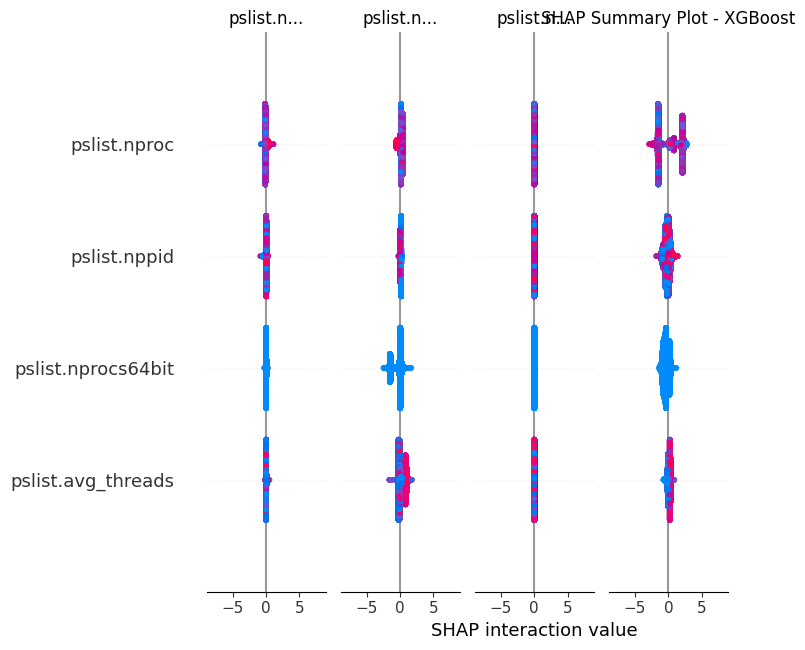

In [25]:
import shap
import matplotlib.pyplot as plt
import numpy as np
# ── 2. SHAP untuk XGBoost ────────────────────────────────────
print("\n--- SHAP Analysis: XGBoost ---")
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

plt.figure()
shap.summary_plot(
    shap_values_xgb, X_train,
    class_names=class_labels,
    show=False
)
plt.title("SHAP Summary Plot - XGBoost")
plt.tight_layout()
plt.savefig("shap_xgb_summary.png", dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── SHAP dari X_train, bukan X_test ──────────────────────────
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)  # ✅ ganti ke X_train

if shap_values_xgb.ndim == 3:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=(0, 2))
else:
    shap_xgb_mean = np.abs(shap_values_xgb).mean(axis=0)

shap_xgb_df = pd.DataFrame({
    'Feature'        : X_train.columns,  # ✅ ganti ke X_train
    'SHAP_Importance': shap_xgb_mean
}).sort_values('SHAP_Importance', ascending=False).reset_index(drop=True)
print("\nTop 20 Features (XGBoost - SHAP):")
print(shap_xgb_df.head(20).to_string(index=False))



Top 20 Features (XGBoost - SHAP):
                        Feature  SHAP_Importance
              svcscan.nservices         1.273329
   handles.avg_handles_per_proc         0.621299
                  handles.nfile         0.487484
                   handles.nkey         0.400050
                 handles.nevent         0.380187
       svcscan.process_services         0.367651
             pslist.avg_threads         0.330435
               handles.nsection         0.322100
                handles.nthread         0.247002
      dlllist.avg_dlls_per_proc         0.245684
             handles.nsemaphore         0.239768
     ldrmodules.not_in_load_avg         0.199223
svcscan.shared_process_services         0.177238
         ldrmodules.not_in_load         0.172393
                   pslist.nppid         0.148001
           malfind.commitCharge         0.142162
                handles.nmutant         0.136019
                svcscan.nactive         0.129485
     ldrmodules.not_in_init_avg   

In [27]:
import numpy as np
from imblearn.over_sampling import SMOTE, BorderlineSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import classification_report
import pandas as pd

# ── 1. Definisi persentil & SMOTE variants ───────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]
from sklearn.preprocessing import MinMaxScaler

smote_variants = {
    # 'SMOTE'           : SMOTE(random_state=42),
    # 'SMOTEENN'        : SMOTEENN(random_state=42),
    'SMOTETomek'      : SMOTETomek(random_state=42),
    # 'BorderlineSMOTE' : BorderlineSMOTE(random_state=42)
}

# ── 2. Loop persentil × SMOTE ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    # Hitung N fitur
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    # Ambil fitur
    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"{'='*60}")

    for smote_name, sampler in smote_variants.items():
        print(f"\n  [{smote_name}]")

        # Resample X_train
        X_res, y_res = sampler.fit_resample(X_train_p, y_train)
        print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
        
        # Normaliszation
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        # Retrain model
        xgb_ps = XGBClassifier(**xgb_model.get_params())
        xgb_ps.fit(X_train_scaled, y_res)

        # Evaluasi di test asli (tidak di-resample)
        y_pred = xgb_ps.predict(X_test_scaled)
        report = classification_report(y_test, y_pred, output_dict=True)

        print(classification_report(y_test, y_pred))

        # Simpan hasil
        key = f'P{P}_{smote_name}'
        results_all[key] = {
            'Persentil'   : P,
            'N Fitur'     : N_FEATURES,
            'SMOTE'       : smote_name,
            'Accuracy'    : report['accuracy'],
            'F1 Macro'    : report['macro avg']['f1-score'],
            'F1 Weighted' : report['weighted avg']['f1-score'],
            'Precision'   : report['macro avg']['precision'],
            'Recall'      : report['macro avg']['recall'],
        }

# ── 3. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 4. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   SMOTE     : {best['SMOTE']}")
print(f"   F1 Macro  : {best['F1 Macro']}")


  Persentil P=10% → 6 fitur

  [SMOTETomek]
  Shape train : (46876, 6) → (90660, 6)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5860
           1       0.61      0.61      0.61      1958
           2       0.67      0.66      0.67      2004
           3       0.59      0.60      0.60      1898

    accuracy                           0.81     11720
   macro avg       0.72      0.72      0.72     11720
weighted avg       0.81      0.81      0.81     11720


  Persentil P=20% → 11 fitur

  [SMOTETomek]
  Shape train : (46876, 11) → (92450, 11)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5860
           1       0.69      0.69      0.69      1958
           2       0.73      0.77      0.75      2004
           3       0.69      0.66      0.67      1898

    accuracy                           0.85     11720
   macro avg       0.78      0.78      0.78     11720
weighted avg

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.combine import SMOTETomek
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd

# ── 1. Definisi persentil & model ───────────────────────────────────────────
percentiles = [10, 20, 30, 40, 50, 60, 70]

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=7,
        learning_rate=0.2,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200,
        max_depth=None,
        learning_rate=0.2,
        class_weight='balanced',
        random_state=42,
        verbose = -1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42
    )
}

sampler = SMOTETomek(random_state=42)


  Persentil P=10% → 6 fitur
  Shape train : (46876, 6) → (90660, 6)

  [XGBoost]
  Training Time : 2.1734s
  Testing Time  : 0.0177s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.61      0.61      0.61      1958
     Spyware       0.67      0.66      0.67      2004
      Trojan       0.59      0.60      0.60      1898

    accuracy                           0.81     11720
   macro avg       0.72      0.72      0.72     11720
weighted avg       0.81      0.81      0.81     11720



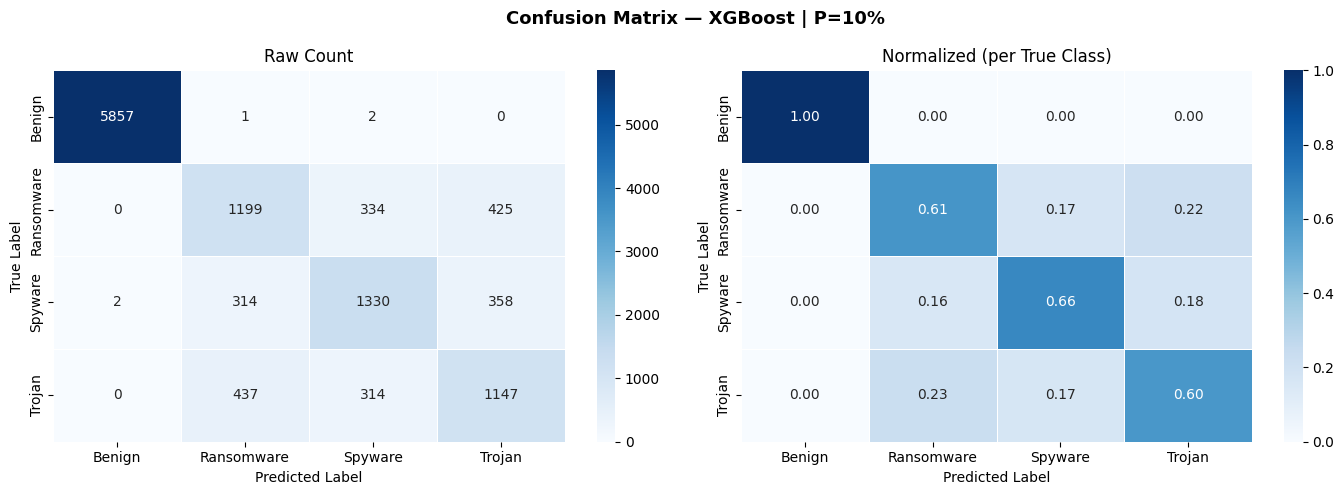


  [LightGBM]
  Training Time : 4.4445s
  Testing Time  : 0.0773s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.62      0.61      0.62      1958
     Spyware       0.68      0.67      0.68      2004
      Trojan       0.60      0.62      0.61      1898

    accuracy                           0.82     11720
   macro avg       0.73      0.73      0.73     11720
weighted avg       0.82      0.82      0.82     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


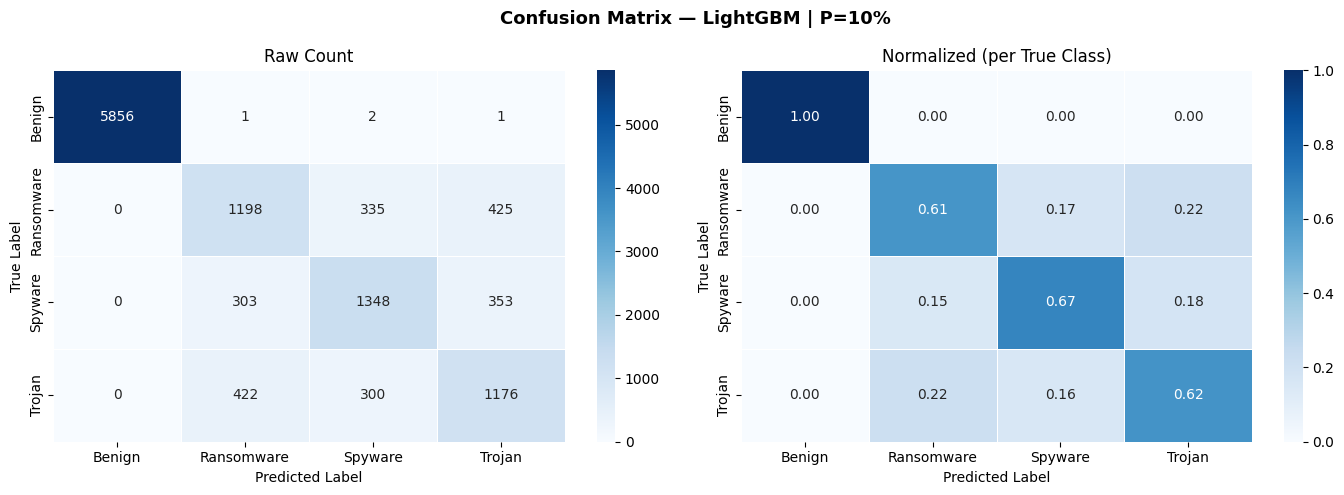


  [RandomForest]
  Training Time : 13.5733s
  Testing Time  : 0.2644s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.63      0.62      0.62      1958
     Spyware       0.69      0.68      0.68      2004
      Trojan       0.61      0.62      0.62      1898

    accuracy                           0.82     11720
   macro avg       0.73      0.73      0.73     11720
weighted avg       0.82      0.82      0.82     11720



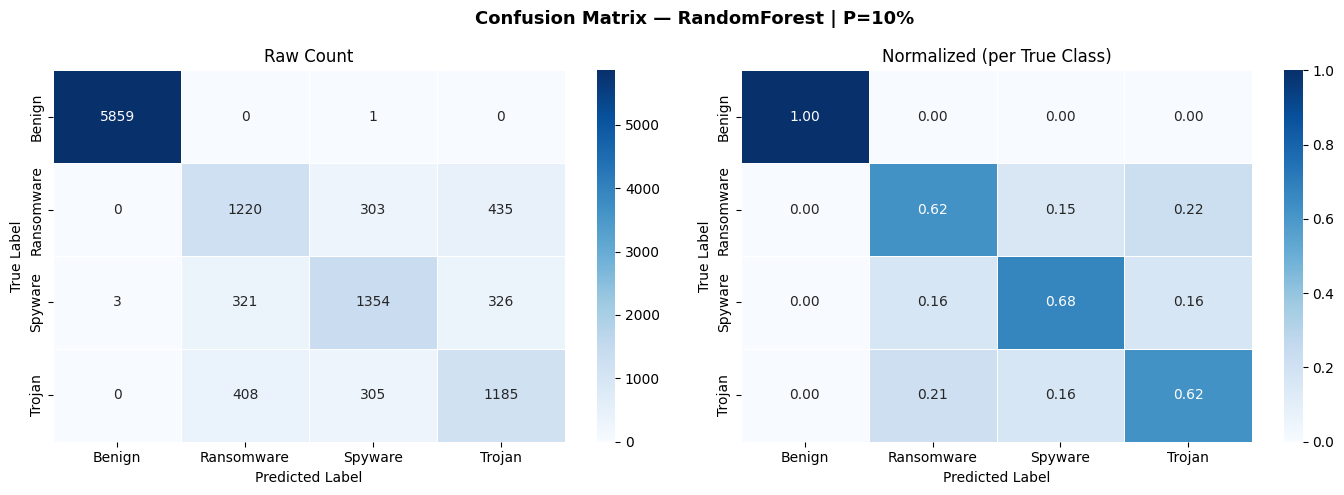


  Persentil P=20% → 11 fitur
  Shape train : (46876, 11) → (92450, 11)

  [XGBoost]
  Training Time : 2.3157s
  Testing Time  : 0.0210s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.69      0.69      0.69      1958
     Spyware       0.73      0.77      0.75      2004
      Trojan       0.69      0.66      0.67      1898

    accuracy                           0.85     11720
   macro avg       0.78      0.78      0.78     11720
weighted avg       0.85      0.85      0.85     11720



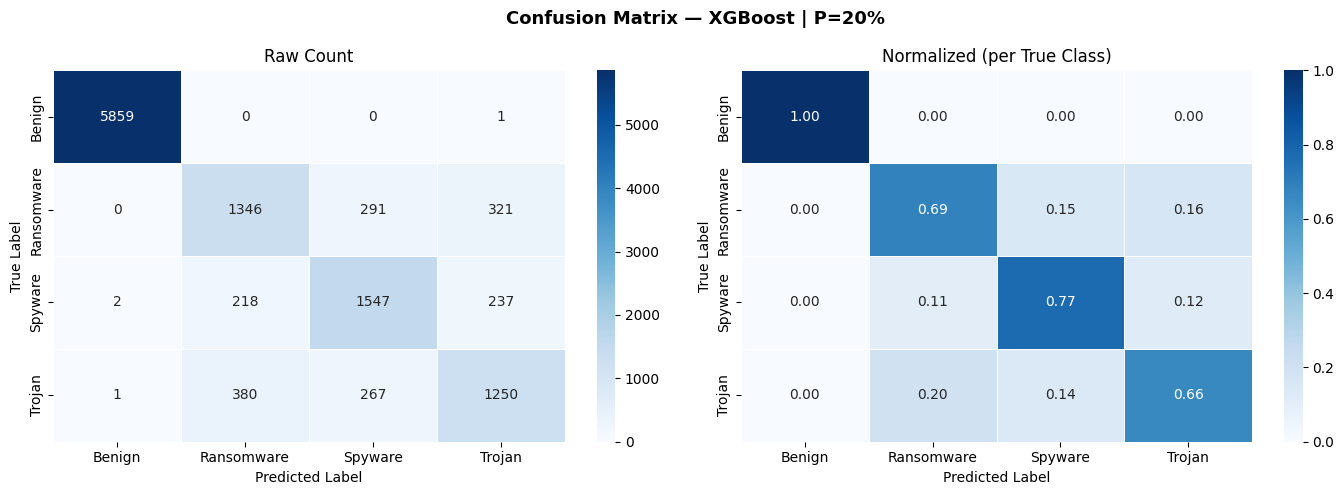


  [LightGBM]
  Training Time : 4.5563s
  Testing Time  : 0.0681s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.69      0.69      0.69      1958
     Spyware       0.73      0.77      0.75      2004
      Trojan       0.69      0.65      0.67      1898

    accuracy                           0.85     11720
   macro avg       0.78      0.78      0.78     11720
weighted avg       0.85      0.85      0.85     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


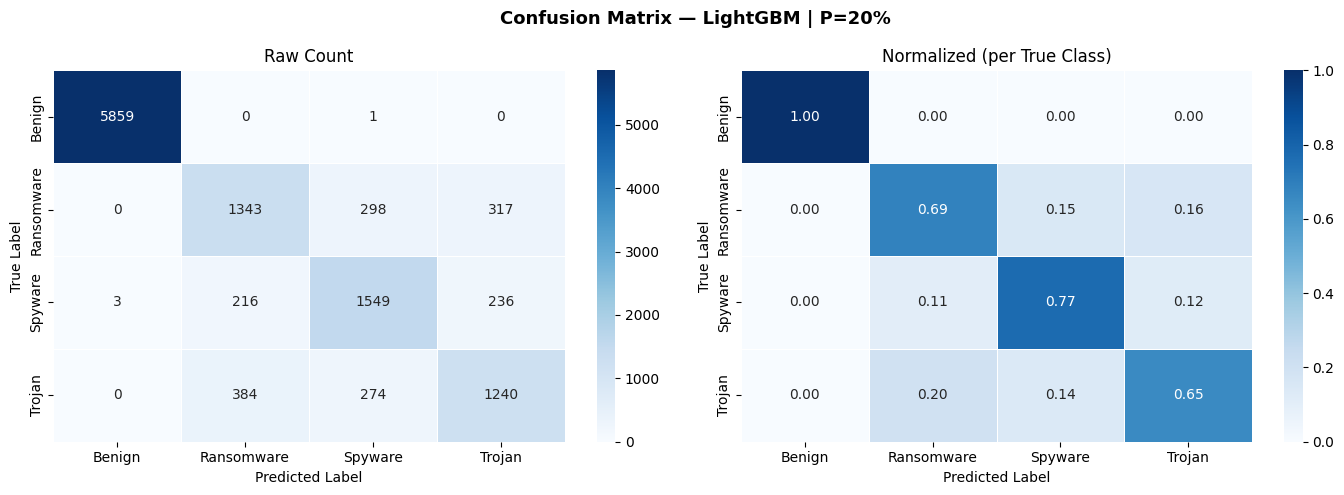


  [RandomForest]
  Training Time : 21.1371s
  Testing Time  : 0.2379s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.70      0.70      0.70      1958
     Spyware       0.76      0.76      0.76      2004
      Trojan       0.70      0.69      0.69      1898

    accuracy                           0.86     11720
   macro avg       0.79      0.79      0.79     11720
weighted avg       0.86      0.86      0.86     11720



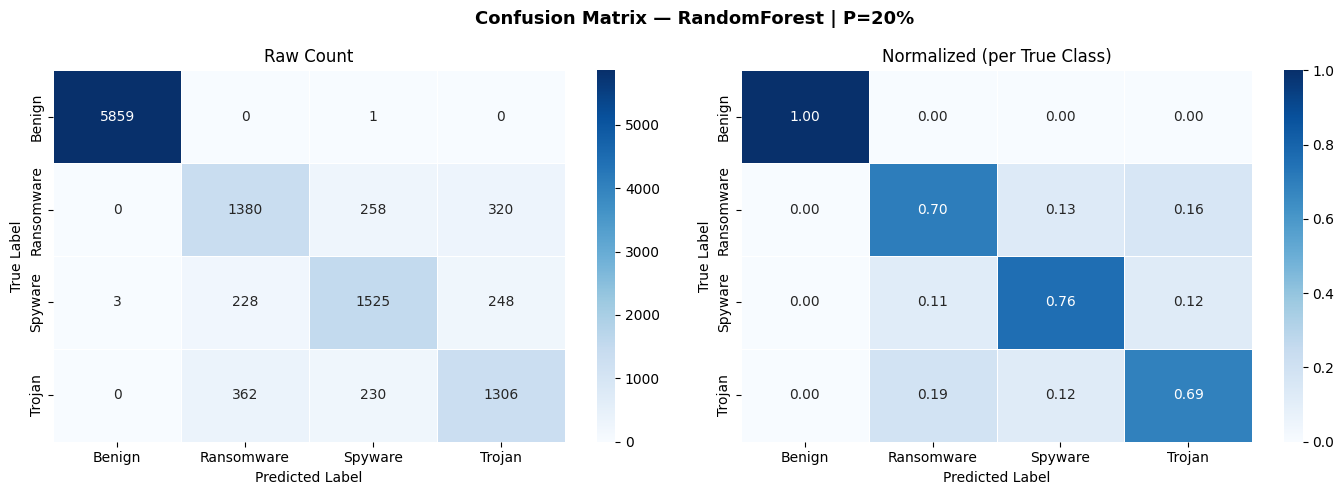


  Persentil P=30% → 17 fitur
  Shape train : (46876, 17) → (92654, 17)

  [XGBoost]
  Training Time : 2.5256s
  Testing Time  : 0.0204s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.73      0.73      1958
     Spyware       0.77      0.80      0.78      2004
      Trojan       0.73      0.71      0.72      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



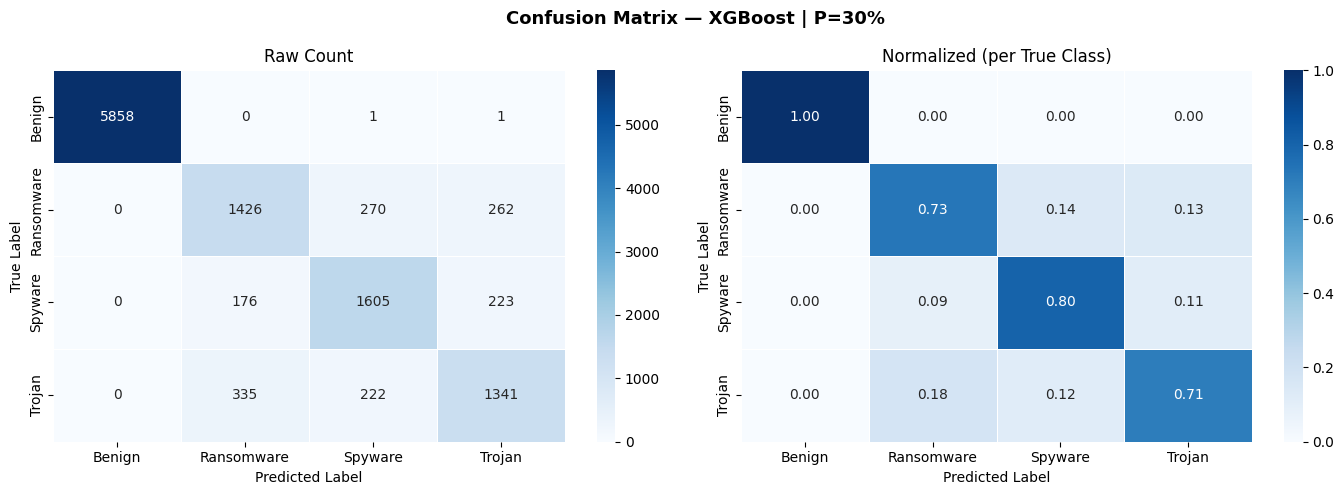


  [LightGBM]
  Training Time : 4.7911s
  Testing Time  : 0.0734s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.74      0.74      1958
     Spyware       0.77      0.81      0.79      2004
      Trojan       0.74      0.70      0.72      1898

    accuracy                           0.88     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.88      0.88      0.88     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


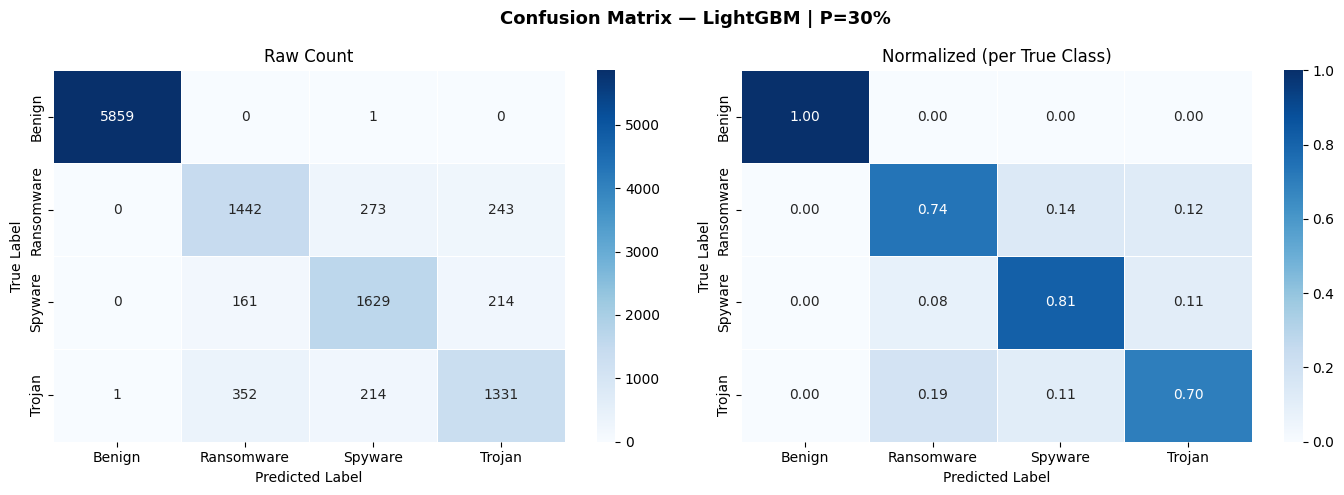


  [RandomForest]
  Training Time : 23.2553s
  Testing Time  : 0.2293s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.73      0.74      1958
     Spyware       0.78      0.80      0.79      2004
      Trojan       0.74      0.72      0.73      1898

    accuracy                           0.88     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.88      0.88      0.88     11720



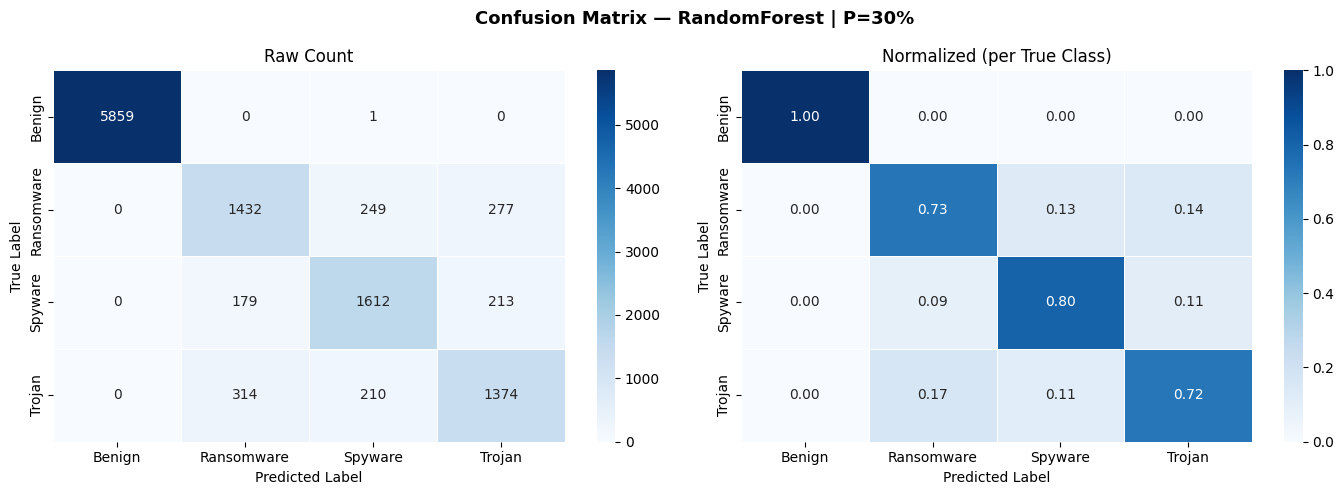


  Persentil P=40% → 22 fitur
  Shape train : (46876, 22) → (92918, 22)

  [XGBoost]
  Training Time : 2.6954s
  Testing Time  : 0.0205s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.74      0.74      1958
     Spyware       0.77      0.81      0.79      2004
      Trojan       0.75      0.71      0.73      1898

    accuracy                           0.88     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.88      0.88      0.88     11720



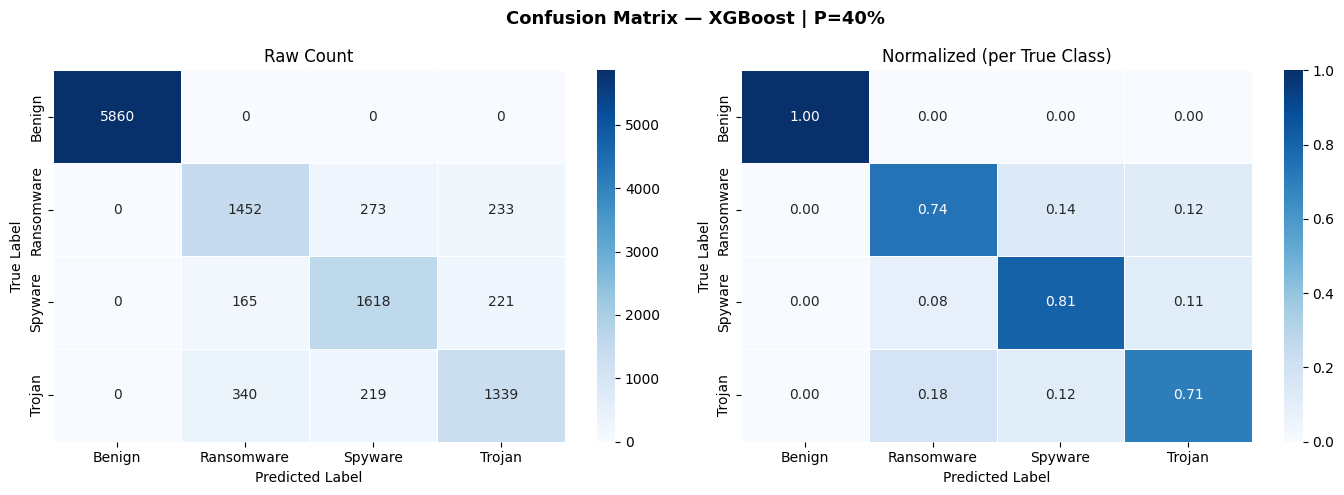


  [LightGBM]
  Training Time : 4.9900s
  Testing Time  : 0.0770s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.75      0.73      0.74      1958
     Spyware       0.77      0.81      0.79      2004
      Trojan       0.74      0.71      0.73      1898

    accuracy                           0.88     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.88      0.88      0.88     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


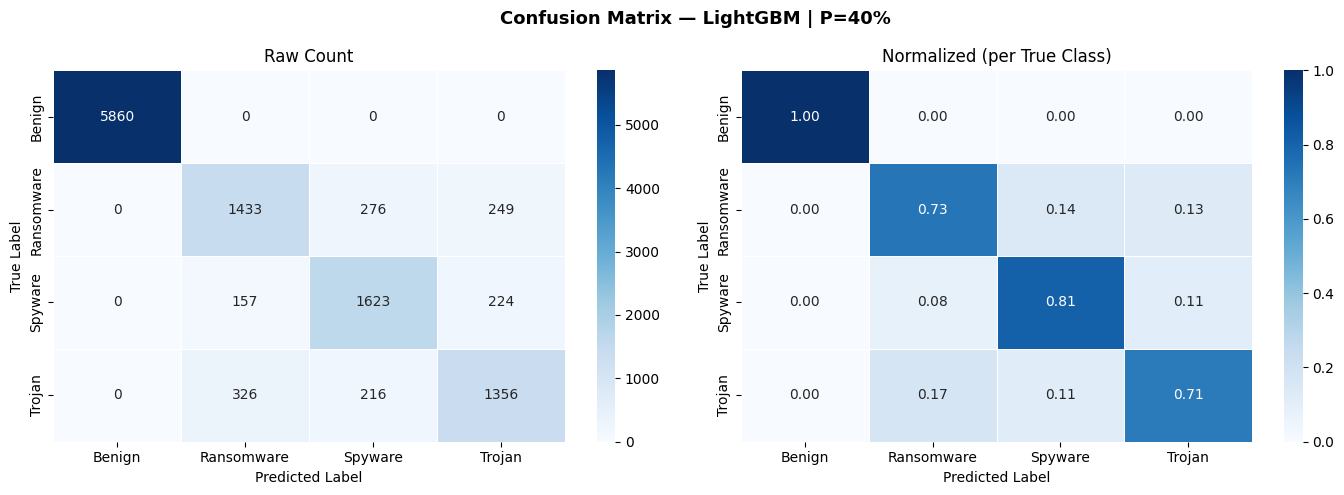


  [RandomForest]
  Training Time : 24.0384s
  Testing Time  : 0.2354s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.75      0.74      0.74      1958
     Spyware       0.78      0.81      0.79      2004
      Trojan       0.74      0.72      0.73      1898

    accuracy                           0.88     11720
   macro avg       0.82      0.82      0.82     11720
weighted avg       0.88      0.88      0.88     11720



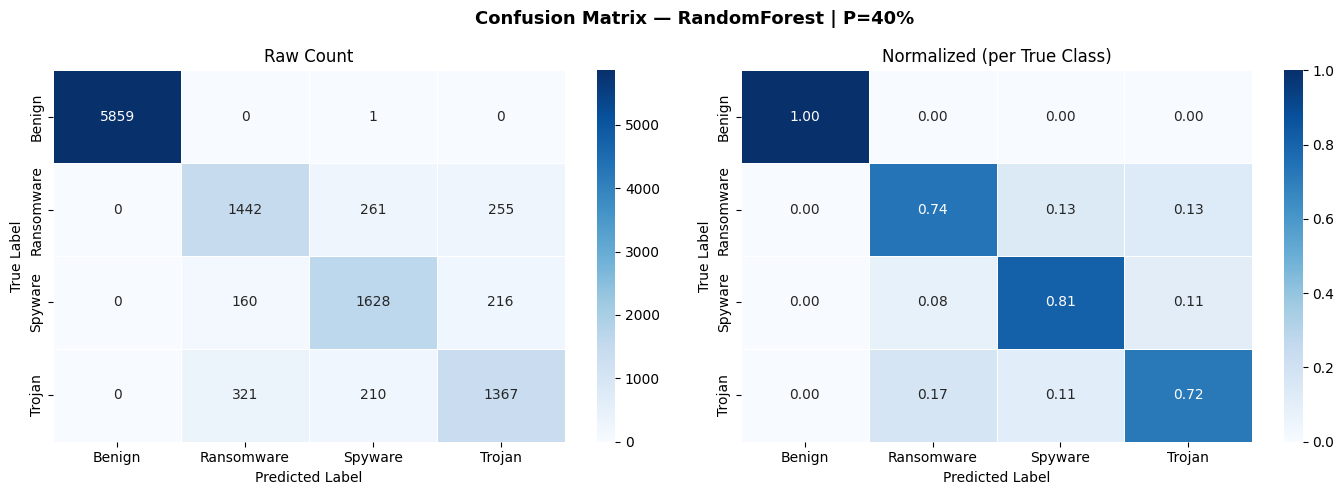


  Persentil P=50% → 28 fitur
  Shape train : (46876, 28) → (92944, 28)

  [XGBoost]
  Training Time : 2.9164s
  Testing Time  : 0.0204s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.73      0.73      1958
     Spyware       0.78      0.82      0.80      2004
      Trojan       0.75      0.71      0.73      1898

    accuracy                           0.88     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.88      0.88      0.88     11720



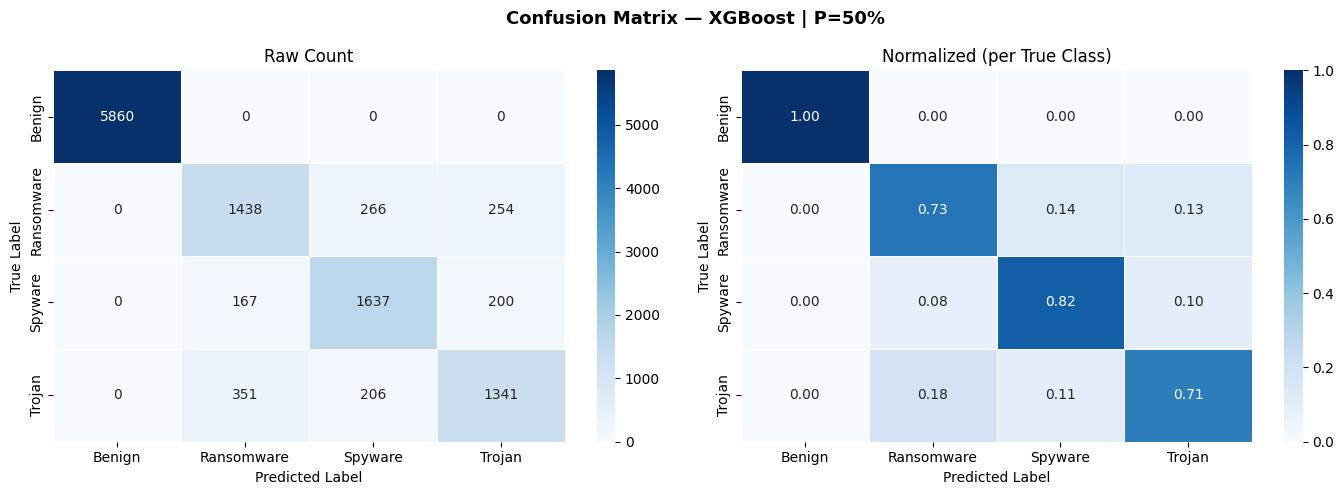


  [LightGBM]
  Training Time : 5.2740s
  Testing Time  : 0.0971s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.73      0.73      0.73      1958
     Spyware       0.77      0.82      0.79      2004
      Trojan       0.74      0.69      0.72      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


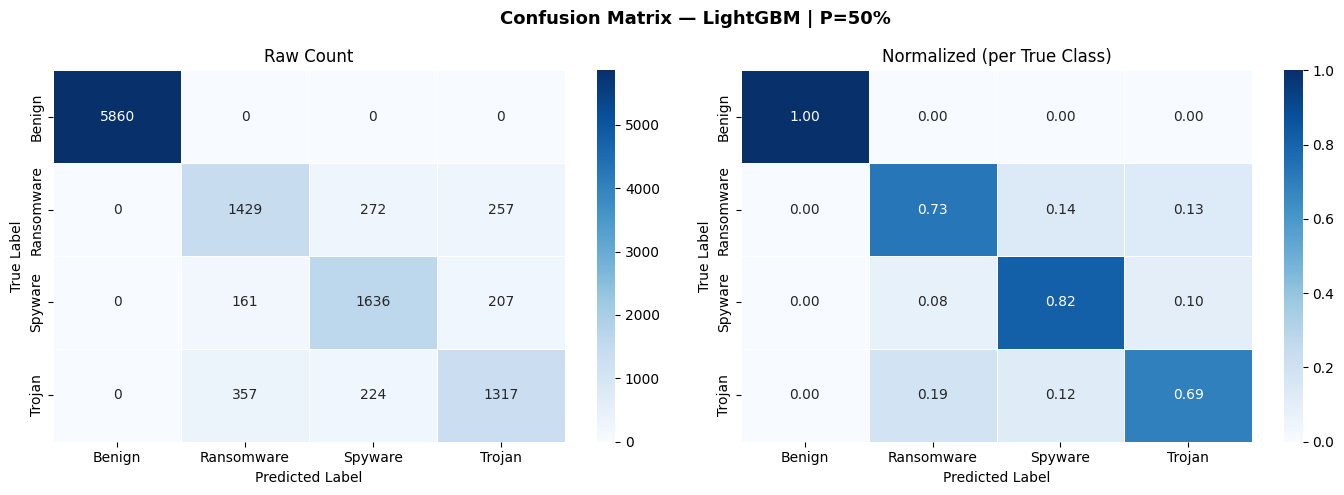


  [RandomForest]
  Training Time : 29.5545s
  Testing Time  : 0.2418s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.73      0.73      1958
     Spyware       0.78      0.81      0.80      2004
      Trojan       0.74      0.72      0.73      1898

    accuracy                           0.88     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.88      0.88      0.88     11720



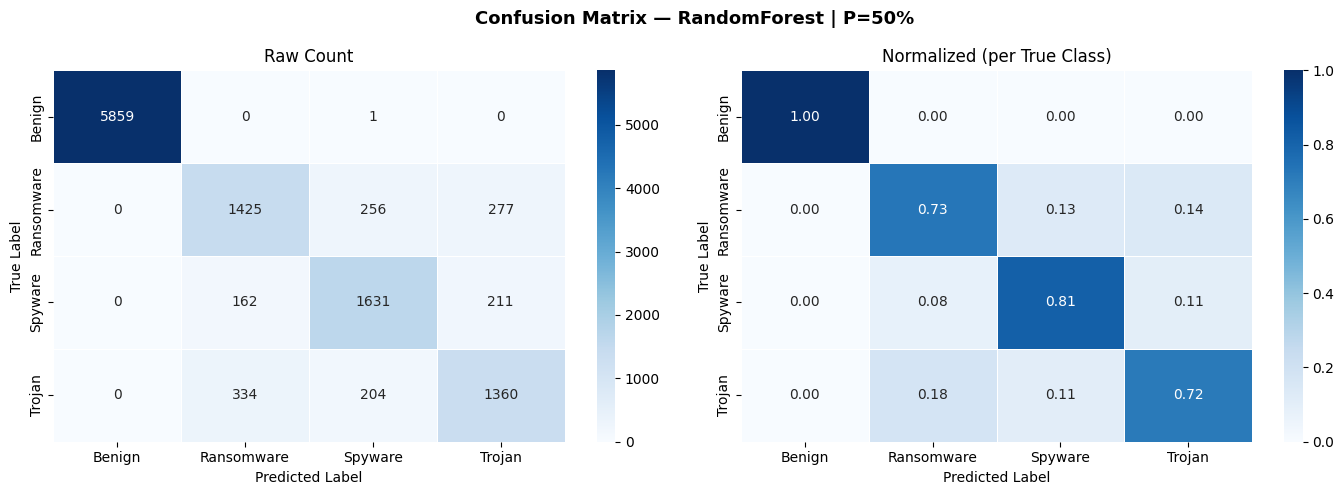


  Persentil P=60% → 33 fitur
  Shape train : (46876, 33) → (93042, 33)

  [XGBoost]
  Training Time : 3.0575s
  Testing Time  : 0.0209s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.73      0.73      0.73      1958
     Spyware       0.77      0.80      0.79      2004
      Trojan       0.74      0.71      0.73      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



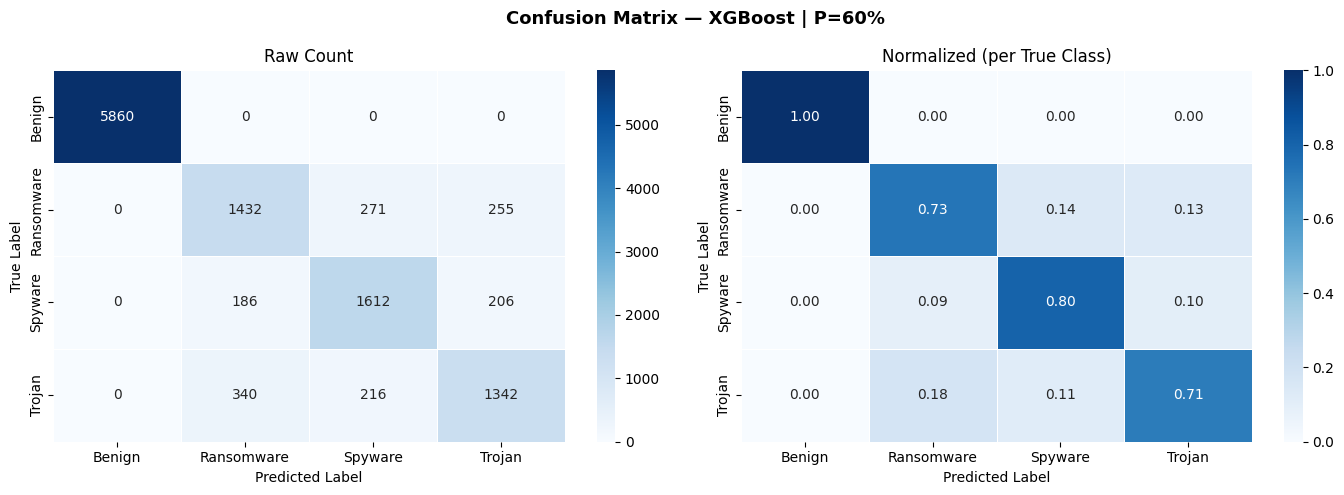


  [LightGBM]
  Training Time : 5.5121s
  Testing Time  : 0.0795s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.73      0.73      0.73      1958
     Spyware       0.76      0.81      0.78      2004
      Trojan       0.74      0.69      0.72      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


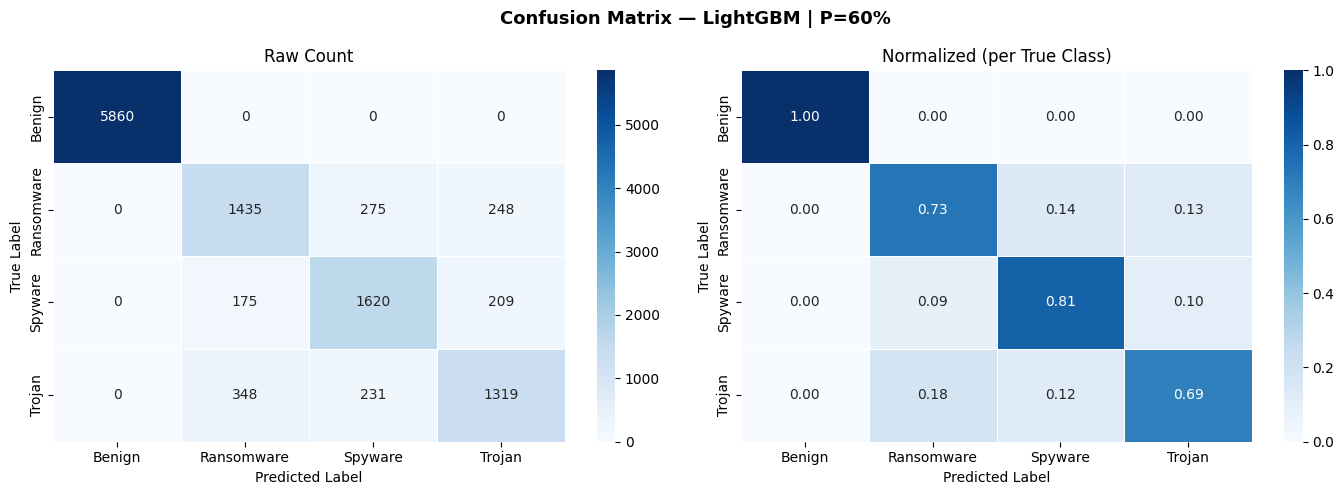


  [RandomForest]
  Training Time : 32.2095s
  Testing Time  : 0.2310s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.73      0.73      0.73      1958
     Spyware       0.77      0.80      0.78      2004
      Trojan       0.73      0.71      0.72      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



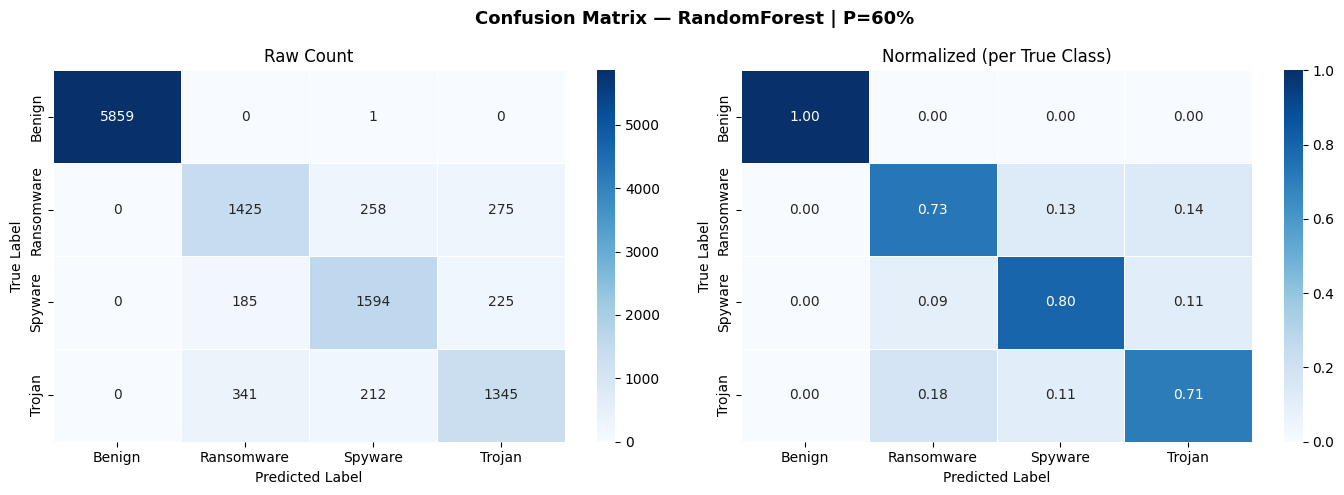


  Persentil P=70% → 39 fitur
  Shape train : (46876, 39) → (93176, 39)

  [XGBoost]
  Training Time : 3.2884s
  Testing Time  : 0.0205s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.74      0.73      0.73      1958
     Spyware       0.77      0.81      0.79      2004
      Trojan       0.74      0.71      0.73      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



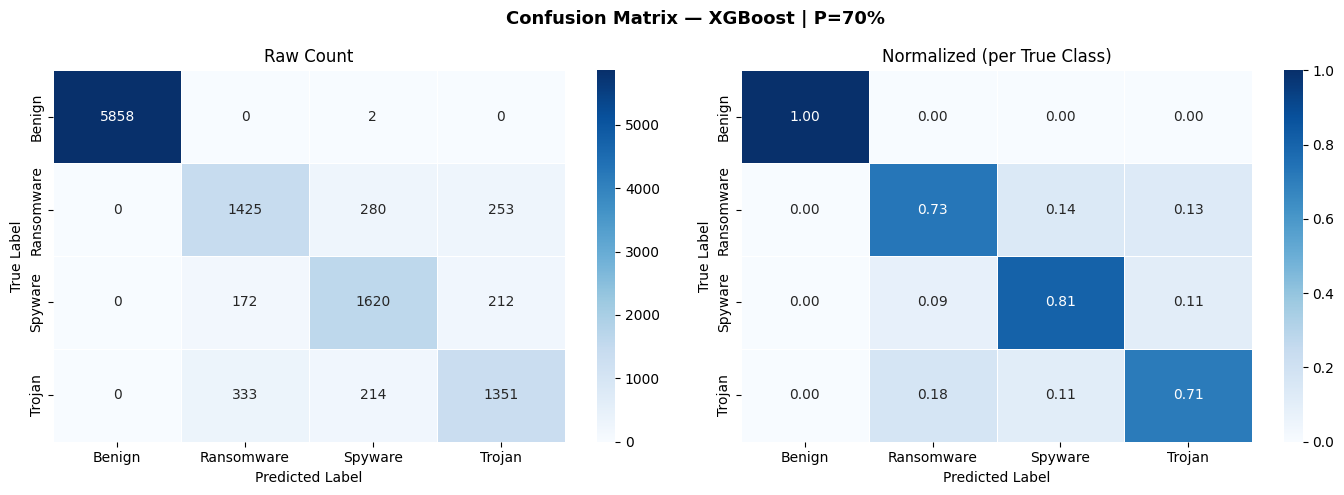


  [LightGBM]
  Training Time : 5.5567s
  Testing Time  : 0.0798s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.73      0.73      0.73      1958
     Spyware       0.77      0.81      0.79      2004
      Trojan       0.73      0.69      0.71      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



/Users/muhammadzuamaalamin/Documents/PengamanJaringan/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


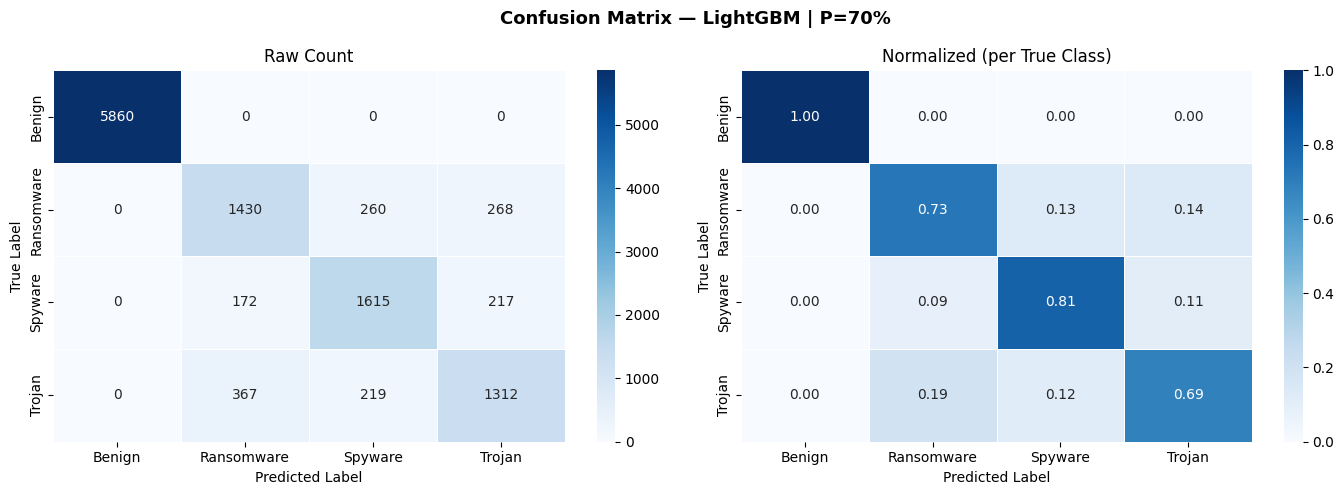


  [RandomForest]
  Training Time : 35.7561s
  Testing Time  : 0.2395s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      5860
  Ransomware       0.72      0.72      0.72      1958
     Spyware       0.77      0.80      0.79      2004
      Trojan       0.73      0.71      0.72      1898

    accuracy                           0.87     11720
   macro avg       0.81      0.81      0.81     11720
weighted avg       0.87      0.87      0.87     11720



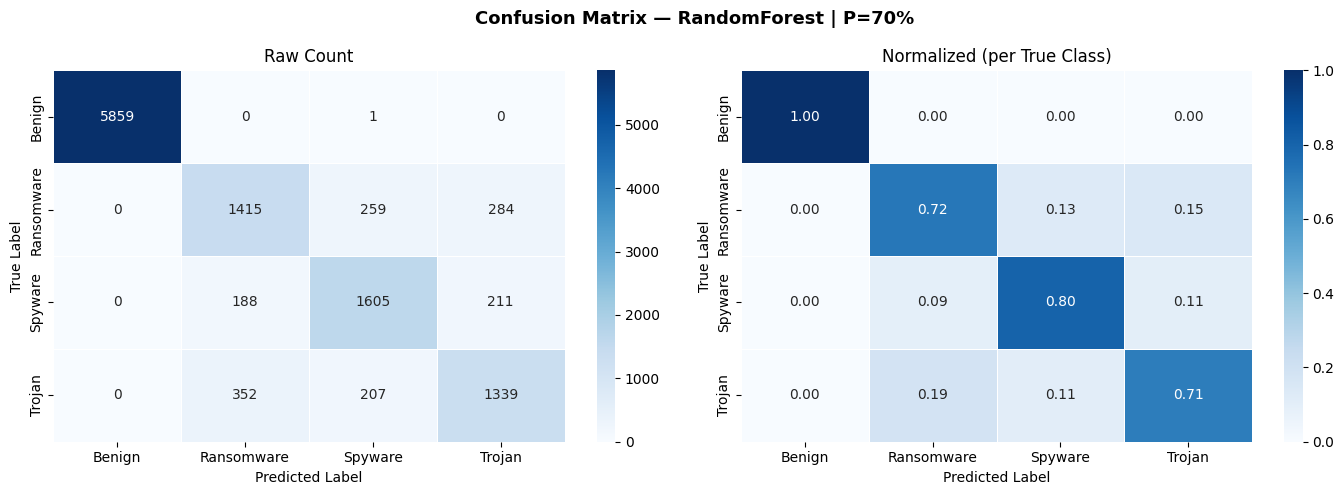


── Perbandingan Semua Kombinasi (SMOTETomek) ──
                 Persentil N Fitur         Model  Accuracy  F1 Macro F1 Weighted Precision Macro Precision Weighted Recall Macro Recall Weighted Training Time Testing Time
P40_RandomForest        40      22  RandomForest  0.878498  0.817048    0.878274        0.817213            0.87828     0.817226        0.878498       24.0384       0.2354
P30_RandomForest        30      17  RandomForest  0.876877  0.814731    0.876723        0.814753           0.876682     0.814875        0.876877       23.2553       0.2293
P50_RandomForest        50      28  RandomForest  0.876706  0.814284    0.876468        0.814342           0.876419     0.814507        0.876706       29.5545       0.2418
P50_XGBoost             50      28       XGBoost  0.876792  0.814262     0.87648        0.814612           0.876529     0.814456        0.876792        2.9164       0.0204
P40_LightGBM            40      22      LightGBM  0.876451  0.813881    0.876186        0.8

In [29]:
# ── 2. Helper plot confusion matrix ─────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, model_name, percentile, class_labels):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name} | P={percentile}%', fontsize=13, fontweight='bold')

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[0], linewidths=0.5
    )
    axes[0].set_title('Raw Count')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=axes[1], linewidths=0.5, vmin=0, vmax=1
    )
    axes[1].set_title('Normalized (per True Class)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

# ── 3. Loop persentil × model ────────────────────────────────────────────────
results_all = {}

for P in percentiles:
    N_total    = len(shap_xgb_df)
    N_FEATURES = int(np.ceil(N_total * P / 100))

    selected_features = shap_xgb_df.head(N_FEATURES)['Feature'].tolist()

    X_train_p = X_train[selected_features]
    X_test_p  = X_test[selected_features]

    X_res, y_res = sampler.fit_resample(X_train_p, y_train)

    print(f"\n{'='*60}")
    print(f"  Persentil P={P}% → {N_FEATURES} fitur")
    print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
    print(f"{'='*60}")

    for model_name, clf in models.items():
        print(f"\n  [{model_name}]")

        clf_fit = clf.__class__(**clf.get_params())

        # Normalization
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_res)
        X_test_scaled  = scaler.transform(X_test_p)

        start = time.time()
        clf_fit.fit(X_train_scaled, y_res)
        train_time = time.time() - start
        print(f"  Training Time : {train_time:.4f}s")

        # ── Testing Time ────────────────────────────────────────────────────
        start = time.time()
        y_pred = clf_fit.predict(X_test_scaled)
        test_time = time.time() - start
        print(f"  Testing Time  : {test_time:.4f}s")

        report = classification_report(y_test, y_pred, output_dict=True)
        print(classification_report(y_test, y_pred, target_names=[str(x) for x in class_labels]))

        # ── Confusion Matrix ────────────────────────────────────────────────
        plot_confusion_matrix(y_test, y_pred, model_name, P, class_labels)

        key = f'P{P}_{model_name}'
        results_all[key] = {
            'Persentil'          : P,
            'N Fitur'            : N_FEATURES,
            'Model'              : model_name,
            'Accuracy'           : report['accuracy'],
            'F1 Macro'           : report['macro avg']['f1-score'],
            'F1 Weighted'        : report['weighted avg']['f1-score'],
            'Precision Macro'    : report['macro avg']['precision'],
            'Precision Weighted' : report['weighted avg']['precision'],
            'Recall Macro'       : report['macro avg']['recall'],
            'Recall Weighted'    : report['weighted avg']['recall'],
            'Training Time'      : round(train_time, 4),
            'Testing Time'       : round(test_time, 4),
        }

# ── 4. Tabel perbandingan ────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Kombinasi (SMOTETomek) ──")
print(results_df.sort_values('F1 Macro', ascending=False).to_string())

# ── 5. Kombinasi terbaik ─────────────────────────────────────────────────────
best = results_df.sort_values('F1 Macro', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Persentil : {best['Persentil']}%")
print(f"   N Fitur   : {best['N Fitur']}")
print(f"   Model     : {best['Model']}")
print(f"   F1 Macro  : {best['F1 Macro']}")

In [30]:
print(f"  Shape train : {X_train_p.shape} → {X_res.shape}")
#                        sebelum SMOTE    sesudah SMOTE

  Shape train : (46876, 39) → (93176, 39)
